# ERCS Experiment Report
## Emergency Response Coordination Simulator
### Adaptive vs Baseline Coordination Under Intermittent Connectivity

MSc Computer Science — University of Liverpool, 2026

This notebook runs the complete ERCS experiment and produces publication-quality
visualizations and statistical analysis for the dissertation.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure src is on the path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))

from ercs.config.parameters import AlgorithmType, SimulationConfig
from ercs.evaluation.metrics import MetricType, PerformanceEvaluator
from ercs.simulation.engine import ExperimentRunner
from ercs.visualization.plots import (
    METRICS_CONFIG,
    apply_thesis_style,
    build_anova_table,
    build_parameter_tables,
    build_results_dataframe,
    build_ttest_table,
    compute_summary_stats,
    plot_box_distributions,
    plot_degradation_lines,
    plot_grouped_bars,
    plot_heatmap,
    save_figure,
)

apply_thesis_style()
FIGURES_DIR = project_root / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Experiment Parameters

All parameters are sourced from published literature and configured
in `configs/default.yaml`.

In [2]:
config = SimulationConfig()

tables = build_parameter_tables(config)
for name, table_df in tables.items():
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    display(table_df.style.hide(axis="index"))


  Network Topology


Parameter,Value,Source
Node count,50 (2 coordination + 48 mobile),Ullah & Qayyum (2022)
Simulation area,3000 x 1500 m²,Ullah & Qayyum (2022)
Incident zone,700 x 600 m²,Ullah & Qayyum (2022)
Radio range,100 m,Ullah & Qayyum (2022)
Buffer size,5 MB,Ullah & Qayyum (2022)
Message size,512 kB,Kumar et al. (2023)
Connectivity scenarios,"75%, 40%, 20%",Karaman et al. (2026)
Mobility model,Random Waypoint,Ullah & Qayyum (2022)
Speed range,0–20 m/s,Ullah & Qayyum (2022)



  PRoPHET Protocol


Parameter,Value,Source
P_init,0.75,Kumar et al. (2023)
β (transitivity),0.25,Kumar et al. (2023)
γ (aging),0.98,Kumar et al. (2023)
Message TTL,300 min,Ullah & Qayyum (2022)
Transmit speed,2 Mbps,Ullah & Qayyum (2022)
Buffer drop policy,Drop Oldest,Ullah & Qayyum (2022)



  Scenario Generation


Parameter,Value,Source
Task arrival,Poisson,Pu et al. (2025)
Message rate,2.0 msgs/min,Kumar et al. (2023)
Urgency distribution,20% H / 50% M / 30% L,Li et al. (2025)
Simulation duration,6000 s (100 min),Ullah & Qayyum (2022)
Runs per configuration,30,Law (2015)



  Coordination


Parameter,Value,Source
Update interval,30 min,Kaji et al. (2025)
Priority levels,3,Rosas et al. (2023)
Path threshold,P > 0.0,Ullah & Qayyum (2022)
Adaptive ordering,Urgency First,Kaji et al. (2025)
Baseline ordering,FCFS,Design decision


In [3]:
connectivity_levels = config.network.connectivity_scenarios
runs_per_config = config.scenario.runs_per_configuration

print("Experimental Design")
print("=" * 40)
print(f"  Algorithms:          2 (Adaptive, Baseline)")
print(f"  Connectivity levels: {len(connectivity_levels)} ({', '.join(f'{c*100:.0f}%' for c in connectivity_levels)})")
print(f"  Runs per config:     {runs_per_config}")
print(f"  Total runs:          {config.total_experimental_runs}")
print(f"  Sim duration:        {config.scenario.simulation_duration_seconds}s ({config.scenario.simulation_duration_seconds // 60} min)")

Experimental Design
  Algorithms:          2 (Adaptive, Baseline)
  Connectivity levels: 3 (75%, 40%, 20%)
  Runs per config:     30
  Total runs:          180
  Sim duration:        6000s (100 min)


## 2. Experiment Execution

Running all 180 simulations (2 algorithms x 3 connectivity levels x 30 runs).

> To run a quick test, change `runs_per_config` below to `5`.

In [4]:
from IPython.display import clear_output

# Change to 5 for a quick test
#RUNS = runs_per_config
RUNS = 5


runner = ExperimentRunner(config=config, base_seed=42)
algorithms = [AlgorithmType.ADAPTIVE, AlgorithmType.BASELINE]
total = len(algorithms) * len(connectivity_levels) * RUNS
start_time = time.time()


def progress_callback(current, total_runs):
    clear_output(wait=True)
    pct = current / total_runs * 100
    bar_len = 40
    filled = int(bar_len * current // total_runs)
    bar = "=" * filled + ">" + " " * max(0, bar_len - filled - 1)
    elapsed = time.time() - start_time
    eta = (elapsed / current) * (total_runs - current) if current > 0 else 0

    alg_idx = (current - 1) // (len(connectivity_levels) * RUNS)
    remainder = (current - 1) % (len(connectivity_levels) * RUNS)
    conn_idx = remainder // RUNS
    run_idx = remainder % RUNS

    alg_name = algorithms[alg_idx].value.capitalize()
    conn_pct = f"{connectivity_levels[conn_idx] * 100:.0f}%"

    print(f"ERCS Experiment Progress")
    print(f"[{bar}] {current}/{total_runs} ({pct:.1f}%)")
    print(f"Current: {alg_name} @ {conn_pct} connectivity, run {run_idx + 1}/{RUNS}")
    print(f"Elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")


results = runner.run_all(
    algorithms=algorithms,
    connectivity_levels=connectivity_levels,
    runs_per_config=RUNS,
    progress_callback=progress_callback,
)

clear_output(wait=True)
elapsed_total = time.time() - start_time
print(f"Experiment complete: {len(results)} runs in {elapsed_total:.1f}s")
print(f"Average time per run: {elapsed_total / len(results):.2f}s")

Experiment complete: 30 runs in 600.1s
Average time per run: 20.00s


In [5]:
df = build_results_dataframe(results)
print(f"Results DataFrame: {df.shape[0]} rows x {df.shape[1]} columns\n")
display(
    df.groupby(["algorithm", "connectivity"])[["delivery_rate", "assignment_rate", "avg_response_time"]]
    .describe()
    .round(4)
)

Results DataFrame: 30 rows x 12 columns



delivery_rate                                      \
                               count     mean      std      min      25%   
algorithm connectivity                                                     
adaptive  0.20                   5.0  21.1000   4.0935  18.2529  19.3883   
          0.40                   5.0  20.7342   4.2819  17.5913  18.0255   
          0.75                   5.0  14.8593  12.0667   1.1355   3.0055   
baseline  0.20                   5.0  18.3466   3.1065  13.4921  18.0380   
          0.40                   5.0  18.0369   4.6139  12.0533  15.6492   
          0.75                   5.0  19.7925  10.4833   6.4044  12.0109   

                                                  assignment_rate          \
                            50%      75%      max           count    mean   
algorithm connectivity                                                      
adaptive  0.20          19.4811  20.0484  28.3295             5.0  0.9036   
          0.40          18.4462  21.8238  27.7841             5.0  0.9002   
          0.75          18.6066  24.9877  26.5615             5.0  0.8893   
baseline  0.20          18.8485  19.2941  22.0601             5.0  0.9116   
          0.40          18.8907  19.0878  24.5033             5.0  0.9144   
          0.75          21.4574  27.6989  31.3908             5.0  0.8855   

                        ...                 avg_response_time            \
                        ...     75%     max             count      mean   
algorithm connectivity  ...                                               
adaptive  0.20          ...  0.9239  0.9353               5.0  886.6103   
          0.40          ...  0.9204  0.9215               5.0  889.3963   
          0.75          ...  0.8992  0.9010               5.0  910.1191   
baseline  0.20          ...  0.9209  0.9356               5.0  921.1740   
          0.40          ...  0.9317  0.9337               5.0  923.0563   
          0.75          ...  0.8923  0.8971               5.0  911.9647   

                                                                         \
                            std       min       25%       50%       75%   
algorithm connectivity                                                    
adaptive  0.20          19.9810  869.7375  877.9558  879.7802  884.5239   
          0.40          28.5471  849.6900  872.2965  894.0636  913.2575   
          0.75          16.4057  885.8854  901.1268  916.6548  921.2795   
baseline  0.20          50.5206  864.3507  867.4604  954.2974  958.9605   
          0.40          15.6124  898.9836  918.4793  924.4988  935.5771   
          0.75          47.5956  841.6744  890.9564  920.4238  943.9888   

                                  
                             max  
algorithm connectivity            
adaptive  0.20          921.0539  
          0.40          917.6737  
          0.75          925.6491  
baseline  0.20          960.8012  
          0.40          937.7428  
          0.75          962.7798  

[6 rows x 24 columns]

## 3. Results Visualization

All figures use a consistent colour scheme:
- **Adaptive** (blue): Network-aware, urgency-first coordination
- **Baseline** (red): Proximity-only, FCFS coordination

In [6]:
# Precompute summary statistics for all metrics
summaries = {}
for metric_key in METRICS_CONFIG:
    summaries[metric_key] = compute_summary_stats(df, metric_key)

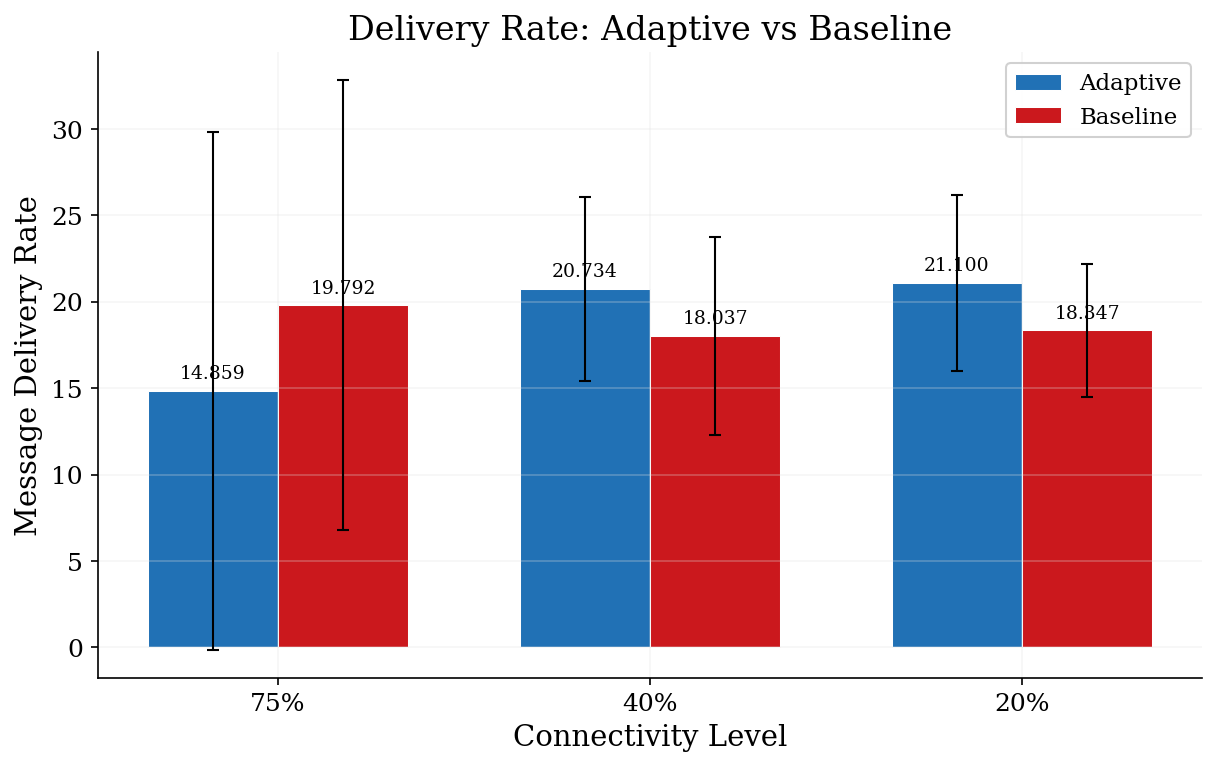

In [7]:
# Figure 1: Delivery Rate — Grouped Bar Chart
fig = plot_grouped_bars(summaries["delivery_rate"], "delivery_rate")
save_figure(fig, "fig_delivery_rate_bars", FIGURES_DIR)
plt.show()

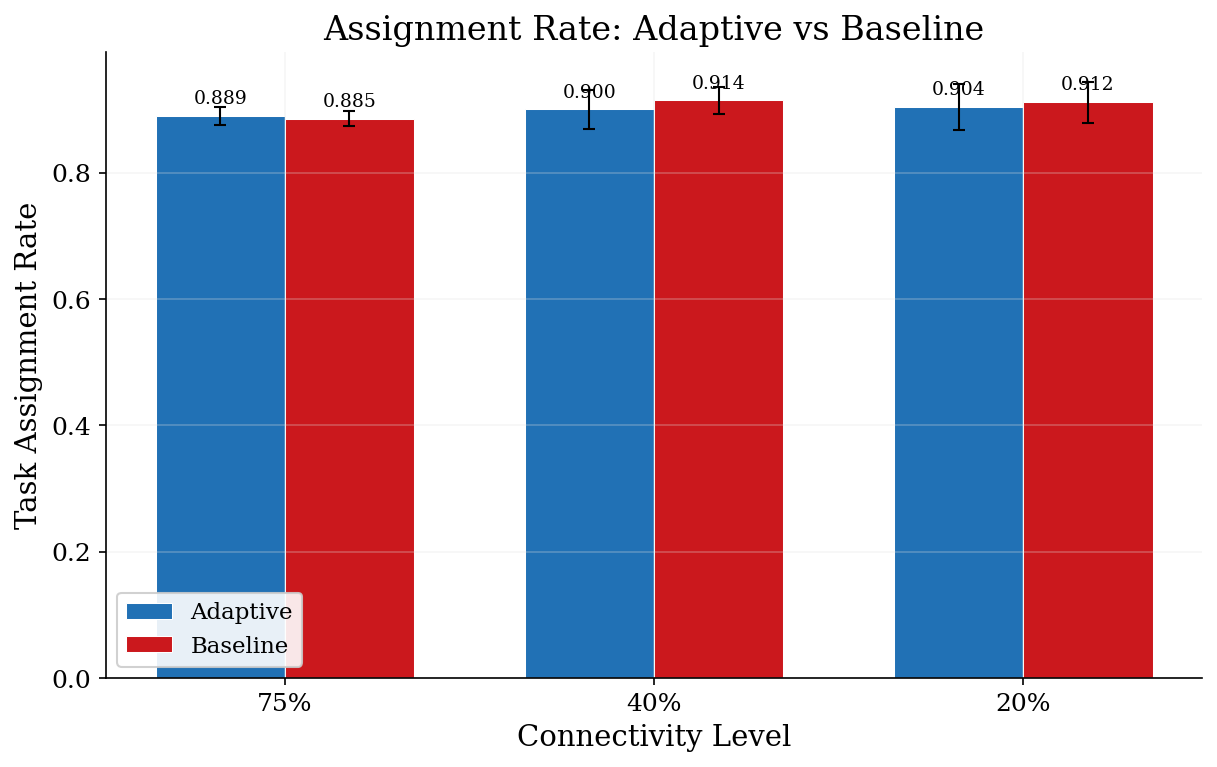

In [8]:
# Figure 2: Assignment Rate — Grouped Bar Chart
fig = plot_grouped_bars(summaries["assignment_rate"], "assignment_rate")
save_figure(fig, "fig_assignment_rate_bars", FIGURES_DIR)
plt.show()

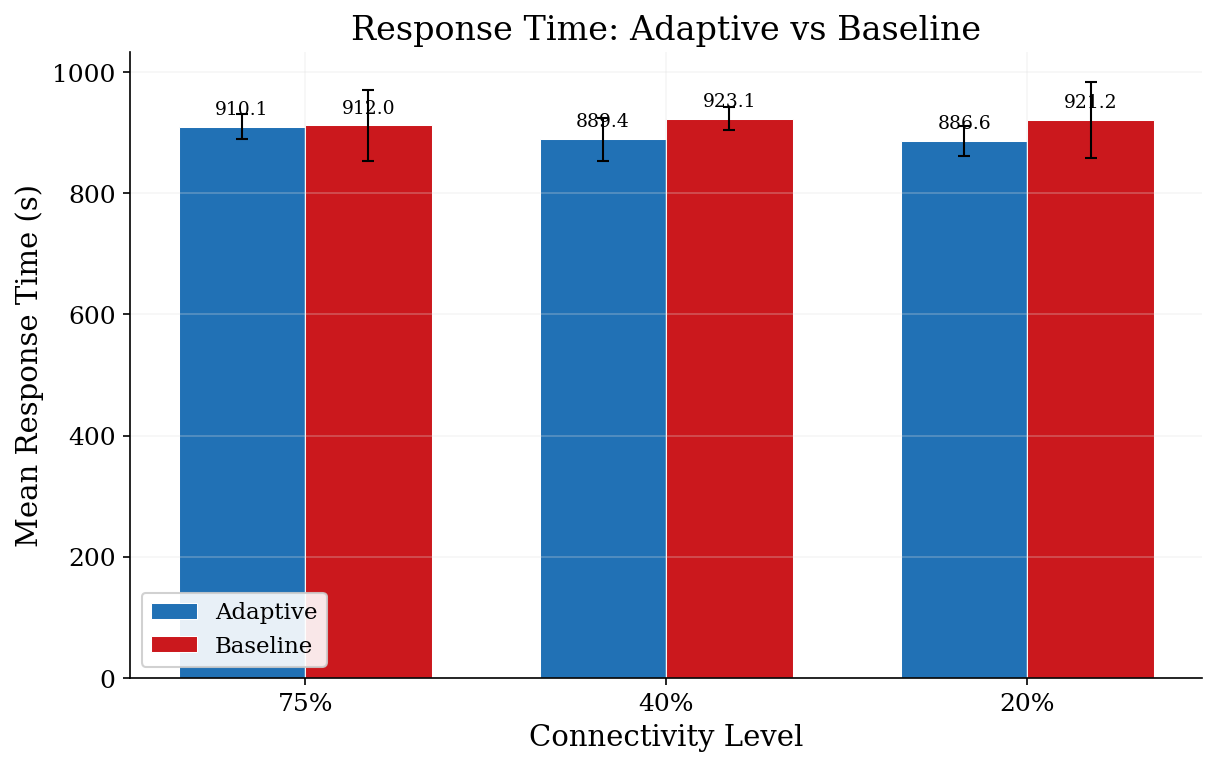

In [9]:
# Figure 3: Response Time — Grouped Bar Chart
fig = plot_grouped_bars(summaries["avg_response_time"], "avg_response_time")
save_figure(fig, "fig_response_time_bars", FIGURES_DIR)
plt.show()

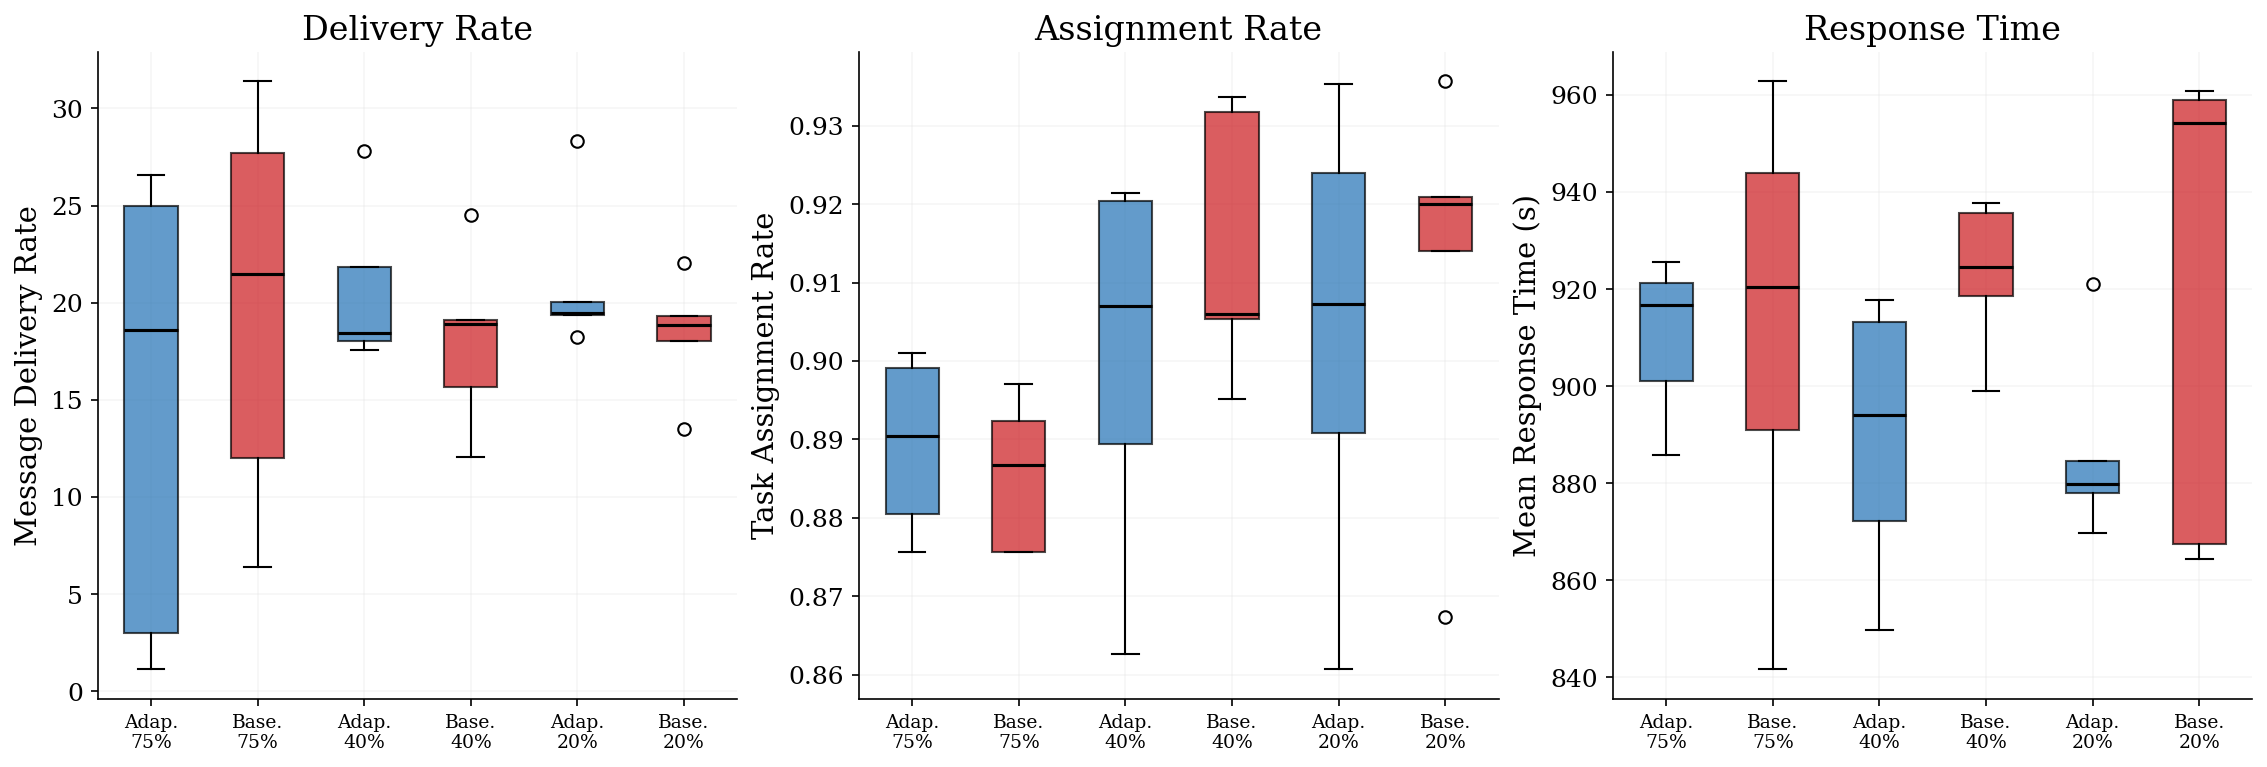

In [10]:
# Figure 4: Box Plot Distributions
fig = plot_box_distributions(df)
save_figure(fig, "fig_box_distributions", FIGURES_DIR)
plt.show()

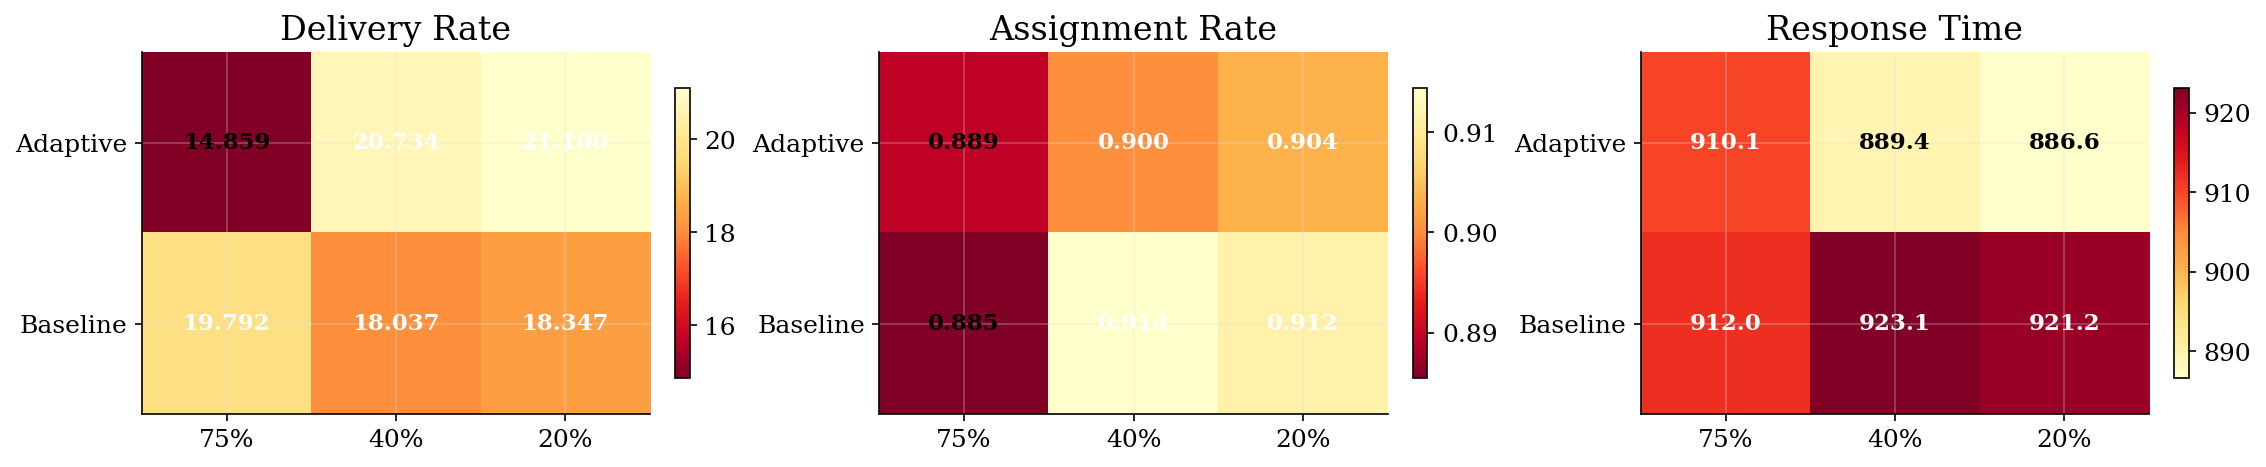

In [11]:
# Figure 5: Performance Heatmap
fig = plot_heatmap(df)
save_figure(fig, "fig_heatmap", FIGURES_DIR)
plt.show()

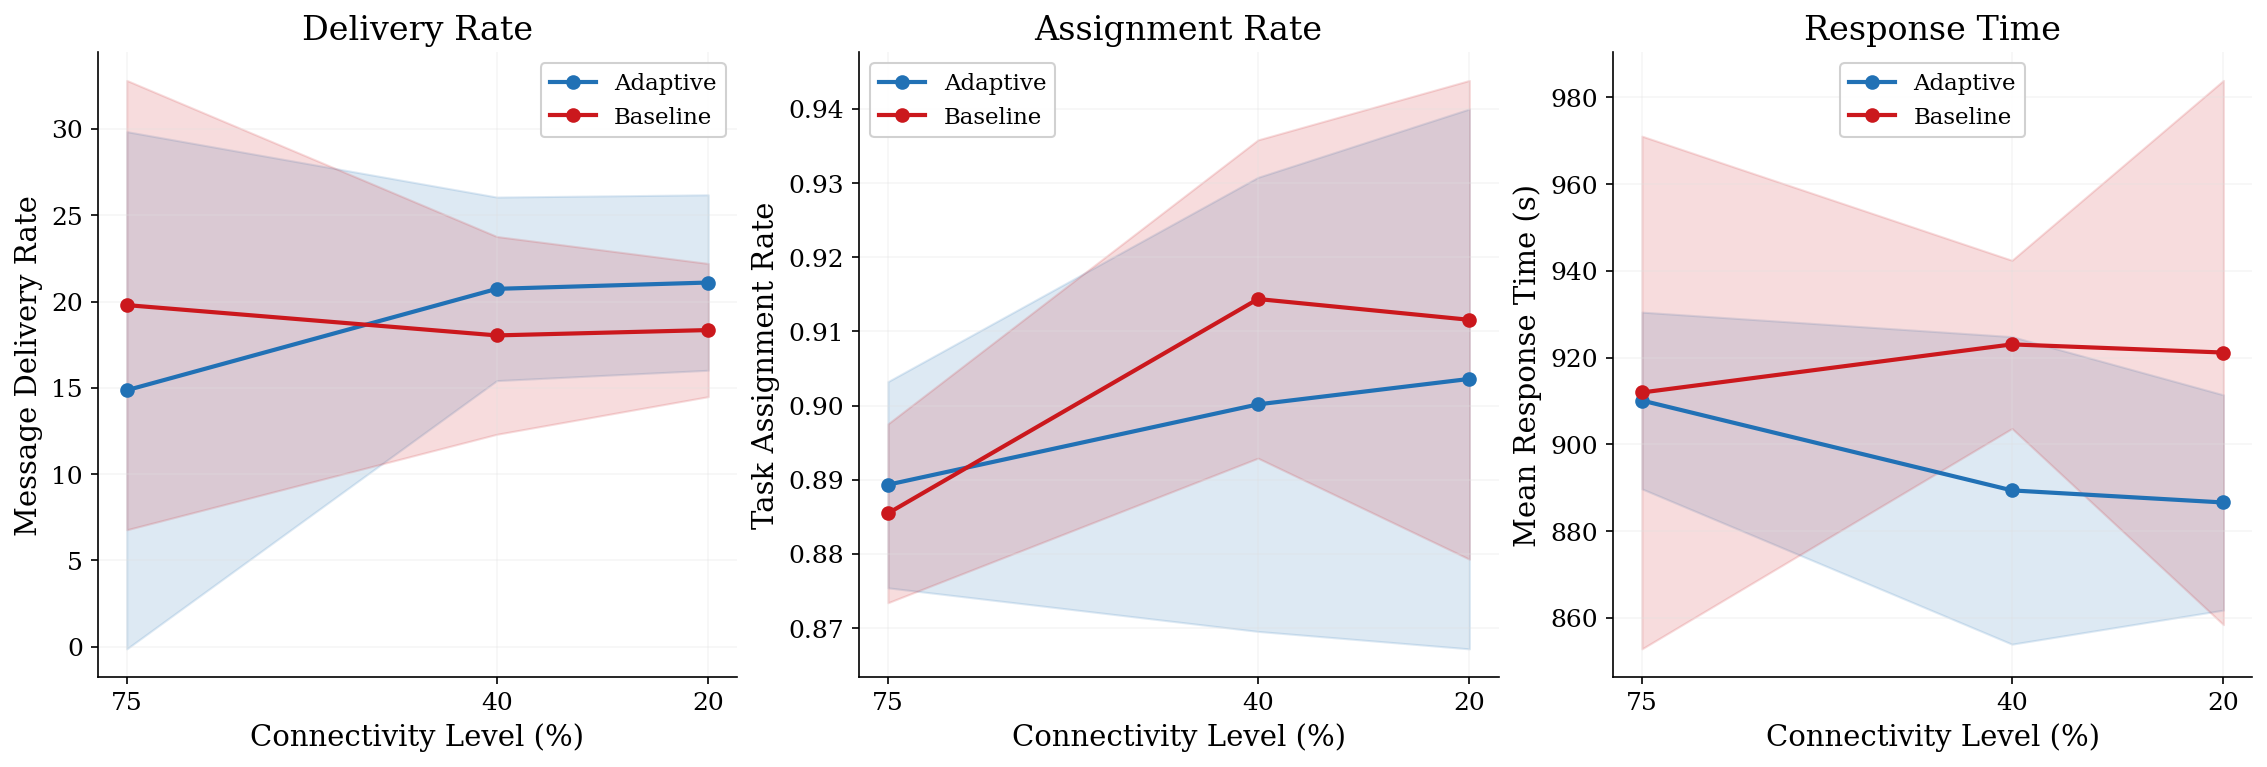

In [12]:
# Figure 6: Connectivity Degradation Lines
fig = plot_degradation_lines(summaries)
save_figure(fig, "fig_degradation_lines", FIGURES_DIR)
plt.show()

In [13]:
# Summary of saved figures
figure_files = sorted(FIGURES_DIR.glob("fig_*.png"))
print(f"\nGenerated {len(figure_files)} figures in {FIGURES_DIR}:")
for f in figure_files:
    print(f"  {f.name}")


Generated 6 figures in /Users/dianafonseca/resilient-emergency-response/outputs/figures:
  fig_assignment_rate_bars.png
  fig_box_distributions.png
  fig_degradation_lines.png
  fig_delivery_rate_bars.png
  fig_heatmap.png
  fig_response_time_bars.png


## 4. Statistical Analysis

Comparing algorithms using Welch's t-test (per connectivity level) and
one-way ANOVA (across connectivity levels). Significance level: \u03b1 = 0.05.

In [14]:
evaluator = PerformanceEvaluator(results)
report = evaluator.generate_report(
    metrics=[MetricType.DELIVERY_RATE, MetricType.ASSIGNMENT_RATE, MetricType.RESPONSE_TIME]
)

In [15]:
# Table 1: Welch's t-test Results
ttest_df = build_ttest_table(report)
display(
    ttest_df.style
    .set_caption("Table 1: Welch's t-test Results (Adaptive vs Baseline)")
    .hide(axis="index")
    .map(lambda v: "font-weight: bold; background-color: #d4edda" if v == "Yes" else "", subset=["Sig."])
)

Metric,Connectivity,Adaptive (mean ± std),Baseline (mean ± std),Improvement,t,p-value,Cohen's d,Sig.
Delivery Rate,Overall,18.8979 ± 7.7710,18.7253 ± 6.3927,+0.92%,0.066,0.9475,0.024,No
Delivery Rate,20%,21.1000 ± 4.0935,18.3466 ± 3.1065,+15.01%,1.198,0.2675,0.758,No
Delivery Rate,40%,20.7342 ± 4.2819,18.0369 ± 4.6139,+14.95%,0.958,0.3662,0.606,No
Delivery Rate,75%,14.8593 ± 12.0667,19.7925 ± 10.4833,-24.92%,-0.690,0.5100,-0.436,No
Assignment Rate,Overall,0.8977 ± 0.0222,0.9038 ± 0.0221,-0.68%,-0.755,0.4566,-0.276,No
Assignment Rate,20%,0.9036 ± 0.0293,0.9116 ± 0.0260,-0.87%,-0.455,0.6616,-0.288,No
Assignment Rate,40%,0.9002 ± 0.0247,0.9144 ± 0.0173,-1.55%,-1.055,0.3257,-0.667,No
Assignment Rate,75%,0.8893 ± 0.0112,0.8855 ± 0.0097,+0.44%,0.582,0.5771,0.368,No
Response Time,Overall,895.3752 ± 23.2733,918.7317 ± 38.3573,-2.54%,-2.016,0.0556,-0.736,No
Response Time,20%,886.6103 ± 19.9810,921.1740 ± 50.5206,-3.75%,-1.423,0.2117,-0.900,No


In [16]:
# Table 2: ANOVA Results
anova_df = build_anova_table(report)
display(
    anova_df.style
    .set_caption("Table 2: One-way ANOVA Results (Effect of Connectivity)")
    .hide(axis="index")
    .map(lambda v: "font-weight: bold; background-color: #d4edda" if v == "Yes" else "", subset=["Sig."])
)

Metric,Algorithm,F,p-value,df,η²,Effect,Sig.
Delivery Rate,Adaptive,1.018,0.3904,"(2, 12)",0.145,large,No
Delivery Rate,Baseline,0.094,0.9114,"(2, 12)",0.015,small,No
Assignment Rate,Adaptive,0.522,0.6060,"(2, 12)",0.080,medium,No
Assignment Rate,Baseline,3.564,0.0610,"(2, 12)",0.373,large,No
Response Time,Adaptive,1.668,0.2295,"(2, 12)",0.218,large,No
Response Time,Baseline,0.104,0.9017,"(2, 12)",0.017,small,No


In [17]:
# Effect Size Interpretation
print("Effect Size Interpretation")
print("=" * 65)
for comp in report.comparisons:
    d = abs(comp.ttest.cohens_d)
    if d < 0.2:
        size = "negligible"
    elif d < 0.5:
        size = "small"
    elif d < 0.8:
        size = "medium"
    else:
        size = "large"
    if comp.connectivity_level is not None:
        label = f"{comp.metric.value} @ {comp.connectivity_level * 100:.0f}%"
    else:
        label = f"{comp.metric.value} (overall)"
    sig = "*" if comp.ttest.significant else ""
    print(f"  {label:40s}  d = {comp.ttest.cohens_d:+.3f} ({size}){sig}")

Effect Size Interpretation
  delivery_rate (overall)                   d = +0.024 (negligible)
  delivery_rate @ 20%                       d = +0.758 (medium)
  delivery_rate @ 40%                       d = +0.606 (medium)
  delivery_rate @ 75%                       d = -0.436 (small)
  assignment_rate (overall)                 d = -0.276 (small)
  assignment_rate @ 20%                     d = -0.288 (small)
  assignment_rate @ 40%                     d = -0.667 (medium)
  assignment_rate @ 75%                     d = +0.368 (small)
  response_time (overall)                   d = -0.736 (medium)
  response_time @ 20%                       d = -0.900 (large)
  response_time @ 40%                       d = -1.463 (large)
  response_time @ 75%                       d = -0.052 (negligible)


## 5. Key Findings

In [18]:
print("KEY FINDINGS")
print("=" * 60)

# 1. Overall delivery rate
overall_dr = next(
    (c for c in report.comparisons
     if c.metric == MetricType.DELIVERY_RATE and c.connectivity_level is None),
    None,
)
if overall_dr:
    print(f"\n1. DELIVERY RATE (Overall)")
    print(f"   Adaptive: {overall_dr.adaptive_stats.mean:.4f} +/- {overall_dr.adaptive_stats.std:.4f}")
    print(f"   Baseline: {overall_dr.baseline_stats.mean:.4f} +/- {overall_dr.baseline_stats.std:.4f}")
    print(f"   Improvement: {overall_dr.improvement:+.2f}%")
    print(f"   Significant: {'Yes' if overall_dr.ttest.significant else 'No'} (p={overall_dr.ttest.p_value:.4f})")

# 2. Where advantage is largest
per_conn = [
    c for c in report.comparisons
    if c.metric == MetricType.DELIVERY_RATE and c.connectivity_level is not None
]
if per_conn:
    best = max(per_conn, key=lambda c: c.improvement)
    print(f"\n2. LARGEST ADAPTIVE ADVANTAGE")
    print(f"   At {best.connectivity_level * 100:.0f}% connectivity: {best.improvement:+.2f}% improvement")

# 3. Connectivity effect
print(f"\n3. CONNECTIVITY EFFECT (ANOVA)")
for key, anova in report.anova_results.items():
    parts = key.rsplit("_", 1)
    metric_name = parts[0].replace("_", " ").title()
    algorithm = parts[1].capitalize() if len(parts) > 1 else "All"
    print(
        f"   {metric_name} ({algorithm}): "
        f"F({anova.df_between},{anova.df_within}) = {anova.f_statistic:.3f}, "
        f"p = {anova.p_value:.4f}, \u03b7\u00b2 = {anova.eta_squared:.3f}"
    )

print("\n" + "=" * 60)
print(f"Experiment complete. All figures saved to: {FIGURES_DIR}")

KEY FINDINGS

1. DELIVERY RATE (Overall)
   Adaptive: 18.8979 +/- 7.7710
   Baseline: 18.7253 +/- 6.3927
   Improvement: +0.92%
   Significant: No (p=0.9475)

2. LARGEST ADAPTIVE ADVANTAGE
   At 20% connectivity: +15.01% improvement

3. CONNECTIVITY EFFECT (ANOVA)
   Delivery Rate (Adaptive): F(2,12) = 1.018, p = 0.3904, η² = 0.145
   Delivery Rate (Baseline): F(2,12) = 0.094, p = 0.9114, η² = 0.015
   Assignment Rate (Adaptive): F(2,12) = 0.522, p = 0.6060, η² = 0.080
   Assignment Rate (Baseline): F(2,12) = 3.564, p = 0.0610, η² = 0.373
   Response Time (Adaptive): F(2,12) = 1.668, p = 0.2295, η² = 0.218
   Response Time (Baseline): F(2,12) = 0.104, p = 0.9017, η² = 0.017

Experiment complete. All figures saved to: /Users/dianafonseca/resilient-emergency-response/outputs/figures
